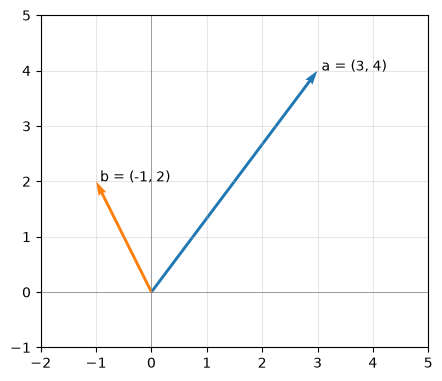

In [3]:
import numpy as np
import matplotlib.pyplot as plt

a = np.array([3,4])
b = np.array([-1,2])

fig, ax = plt.subplots(figsize=(5,5))
ax.quiver(0, 0, a[0], a[1], angles='xy', scale_units='xy', scale=1, color='tab:blue')
ax.quiver(0, 0, b[0], b[1], angles='xy', scale_units='xy', scale=1, color='tab:orange')
ax.text(a[0], a[1], " a = (3, 4)")
ax.text(b[0], b[1], " b = (-1, 2)")

ax.set_xlim(-2, 5)
ax.set_ylim(-1, 5)
ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.set_aspect("equal")
ax.grid(alpha=0.3)
plt.show()

In [4]:
def magnitude(v):
    total = 0
    for x in v:
        total += x ** 2
    return total ** 0.5

print(magnitude(a))   # 5.0
assert np.allclose(magnitude(a), np.linalg.norm(a))


5.0


In [5]:
def normalize(v):
    m = magnitude(v)
    return np.array([x / m for x in v])

a_unit = normalize(a)
print(a_unit)              # [0.6 0.8]
print(magnitude(a_unit))   # 1.0
assert np.allclose(a_unit, a / np.linalg.norm(a))


[0.6 0.8]
1.0


In [6]:
#[royalty, male, female]
embeddings = {
    "king":   np.array([0.95, 0.85, 0.10]),
    "queen":  np.array([0.93, 0.12, 0.88]),
    "man":    np.array([0.10, 0.90, 0.05]),
    "woman":  np.array([0.08, 0.10, 0.92]),
    "prince": np.array([0.75, 0.80, 0.08]),
    "apple":  np.array([0.02, 0.05, 0.04]),
}

result = embeddings["king"] - embeddings["man"] + embeddings["woman"]
print(result)   # [0.93 0.05 0.97]


[0.93 0.05 0.97]


In [7]:
def distance(u, v):
    return magnitude(u - v)

for word, vec in embeddings.items():
    print(f"{word:7s} {distance(result, vec):.3f}")

closest = min(embeddings, key=lambda w: distance(result, embeddings[w]))
print("closest:", closest)


king    1.182
queen   0.114
man     1.503
woman   0.853
prince  1.178
apple   1.301
closest: queen
